In [1]:
from statistics import correlation, linear_regression

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv('insurance.csv')
# data.info()
data.describe()


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [3]:
data.isnull().sum()


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [4]:
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

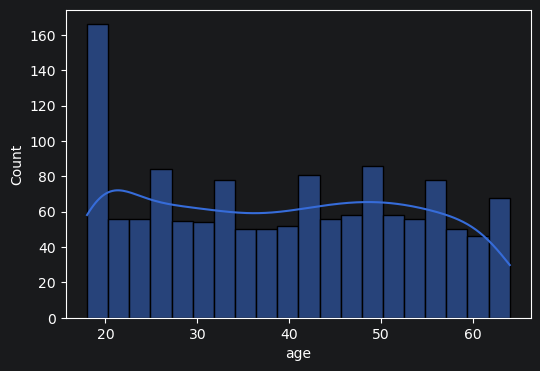

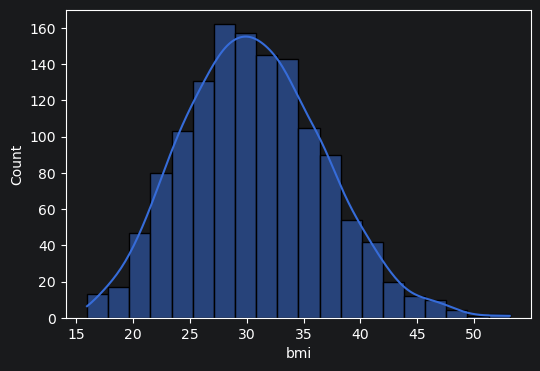

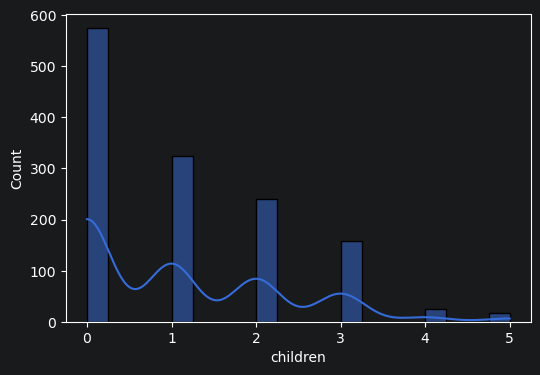

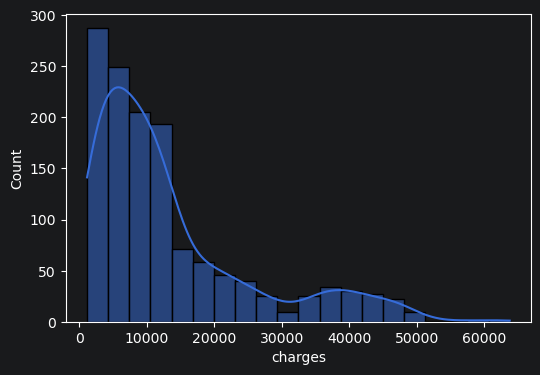

In [5]:
numeric_colums=['age','bmi','children','charges']
for col in numeric_colums:
    plt.figure(figsize=(6,4))
    sns.histplot(data[col],kde = True,bins= 20)

<Axes: >

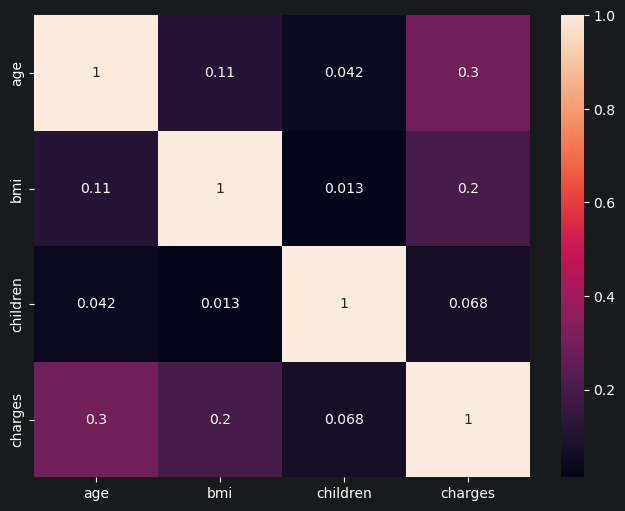

In [6]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(numeric_only=True),annot=True)

data cleanning


In [7]:
df_cleaned = data.copy()
df_cleaned.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
df_cleaned.drop_duplicates(inplace=True)
df_cleaned.shape

(1337, 7)

In [9]:
df_cleaned["sex"].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [10]:
#labeling male as 0 female as 1
df_cleaned['sex'] = df_cleaned['sex'].map({"male" : 0, "female" : 1} )
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [11]:
df_cleaned['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [12]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({'no' : 0 , 'yes' : 1})
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [13]:
df_cleaned.rename(columns={
    'sex' : 'is_female',
    'smoker' : 'is smoker',
                            },inplace=True)

In [14]:
df_cleaned.head()

,age,is_female,bmi,children,is smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [15]:
df_cleaned = pd.get_dummies(df_cleaned,columns= ['region'],drop_first=True)
df_cleaned.head()

,age,is_female,bmi,children,is smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [16]:
df_cleaned = df_cleaned.astype(int)
df_cleaned.head()

,age,is_female,bmi,children,is smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0


##Feature ENg

In [17]:
#adding extra colums with bmi category

In [18]:
df_cleaned['bmi_category'] = pd.cut(df_cleaned['bmi'],bins=[0,18.5,24.9,29.9,float('inf')],labels=['underweight','normal', 'overweight', 'obese'])

In [19]:
df_cleaned.head()

,age,is_female,bmi,children,is smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,overweight
1,18,0,33,1,0,1725,0,1,0,obese
2,28,0,33,3,0,4449,0,1,0,obese
3,33,0,22,0,0,21984,1,0,0,normal
4,32,0,28,0,0,3866,1,0,0,overweight


In [20]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['bmi_category'], drop_first= True)
df_cleaned = df_cleaned.astype(int)
df_cleaned.head()

,age,is_female,bmi,children,is smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


In [21]:
from sklearn.preprocessing import StandardScaler
cols = ['age','bmi','children']
scaler = StandardScaler()
df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [22]:
df_cleaned.head()


,age,is_female,bmi,children,is smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0


In [23]:
from scipy.stats import pearsonr


selected_features = [
    'age', 'bmi','children','is_female','is smoker',
    'region_northwest','region_southwest','region_southeast','bmi_category_normal',
    'bmi_category_overweight','bmi_category_obese'
]

correlation = {
    feature : pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
}

correlation_df = pd.DataFrame(list(correlation.items()),columns=['feature', 'pearson Correlation'])
correlation_df.sort_values(by='pearson Correlation',ascending= False)


final_df = df_cleaned[['age','is_female','is smoker','charges','bmi','children','region_southeast','bmi_category_obese']]

In [24]:
final_df

,age,is_female,is smoker,charges,bmi,children,region_southeast,bmi_category_obese
0,-1.440418,1,1,16884,-0.517949,-0.909234,0,0
1,-1.511647,0,0,1725,0.462463,-0.079442,1,1
2,-0.799350,0,0,4449,0.462463,1.580143,1,1
3,-0.443201,0,0,21984,-1.334960,-0.909234,0,0
4,-0.514431,0,0,3866,-0.354547,-0.909234,0,0
...,...,...,...,...,...,...,...,...
1333,0.767704,0,0,10600,-0.027743,1.580143,0,1
1334,-1.511647,1,0,2205,0.135659,-0.909234,0,1
1335,-1.511647,1,0,1629,0.952670,-0.909234,1,1
1336,-1.297958,1,0,2007,-0.844753,-0.909234,0,0


In [25]:
from sklearn.model_selection import train_test_split

X = final_df.drop('charges',axis=1)
y = final_df['charges']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
y_predi = model.predict(X_test)

In [29]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test,y_predi)
r2

0.8040712413347116